In [1]:
import pandas as pd

df = pd.read_csv("/content/Social_Media_Data.csv")

print(df.head())
print(df.shape)

    Post_ID Username  Platform                                      Text  \
0  POST0001  user_32  Facebook      New technology is making life easier   
1  POST0002  user_55   YouTube  Online learning is becoming more popular   
2  POST0003  user_26   YouTube   Fitness and healthy living are trending   
3  POST0004  user_44    Reddit       The latest AI tools are very useful   
4  POST0005  user_46   Twitter      Technology is changing everyday life   

        Topic  Likes  Shares  Comments        Date  
0  Technology   1833     286       754  2026-01-27  
1   Education    265      62        95  2026-02-25  
2     Fitness   4469     860       225  2026-04-25  
3          AI   2281     319       220  2026-07-15  
4  Technology   2822    1237       270  2026-07-26  
(1000, 9)


In [2]:
import re

df = df.drop_duplicates()
df = df.dropna()

df["Clean_Text"] = df["Text"].str.lower()
df["Clean_Text"] = df["Clean_Text"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

print(df[["Text", "Clean_Text"]].head())

                                       Text  \
0      New technology is making life easier   
1  Online learning is becoming more popular   
2   Fitness and healthy living are trending   
3       The latest AI tools are very useful   
4      Technology is changing everyday life   

                                 Clean_Text  
0      new technology is making life easier  
1  online learning is becoming more popular  
2   fitness and healthy living are trending  
3       the latest ai tools are very useful  
4      technology is changing everyday life  


In [3]:
print("Trending Topics:")

trending = df["Topic"].value_counts()

print(trending)

Trending Topics:
Topic
Technology    118
Fashion       110
Food          107
Travel        106
Gaming        103
Sports        100
Education      96
Fitness        90
Movies         89
AI             81
Name: count, dtype: int64


In [4]:
interest = df.groupby("Topic")[["Likes", "Shares", "Comments"]].sum()

interest["Total_Engagement"] = (
    interest["Likes"] +
    interest["Shares"] +
    interest["Comments"]
)

print(interest.sort_values("Total_Engagement", ascending=False))

             Likes  Shares  Comments  Total_Engagement
Topic                                                 
Technology  300486   91280     43013            434779
Travel      277339   86289     44969            408597
Fashion     272928   83728     46359            403015
Sports      270357   71245     41155            382757
Food        259026   76872     46205            382103
Gaming      243594   76074     42548            362216
Education   250117   72337     38478            360932
Fitness     249385   64976     36908            351269
Movies      227248   66955     37749            331952
AI          192876   60317     32371            285564


In [5]:
popular_topic = interest["Total_Engagement"].idxmax()

print("Most Popular Topic:", popular_topic)

Most Popular Topic: Technology


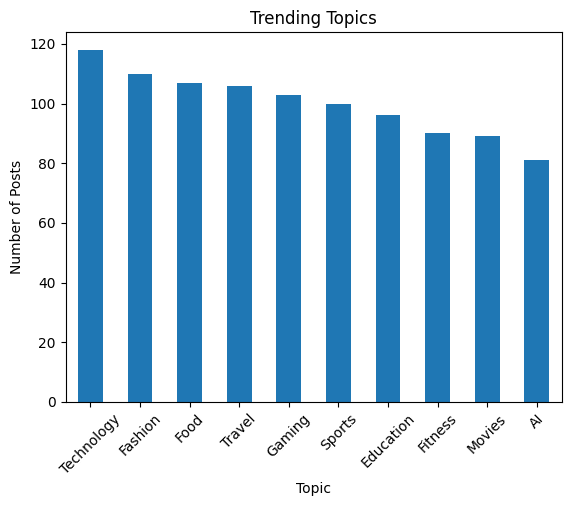

In [6]:
import matplotlib.pyplot as plt

df["Topic"].value_counts().plot(kind="bar")

plt.title("Trending Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

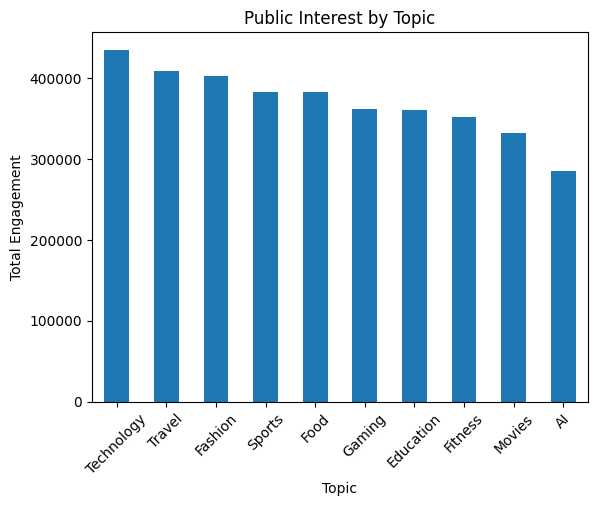

In [7]:
interest["Total_Engagement"].sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Public Interest by Topic")
plt.xlabel("Topic")
plt.ylabel("Total Engagement")
plt.xticks(rotation=45)
plt.show()

Posts by Platform:
Platform
Reddit       214
Twitter      205
Facebook     200
YouTube      196
Instagram    185
Name: count, dtype: int64


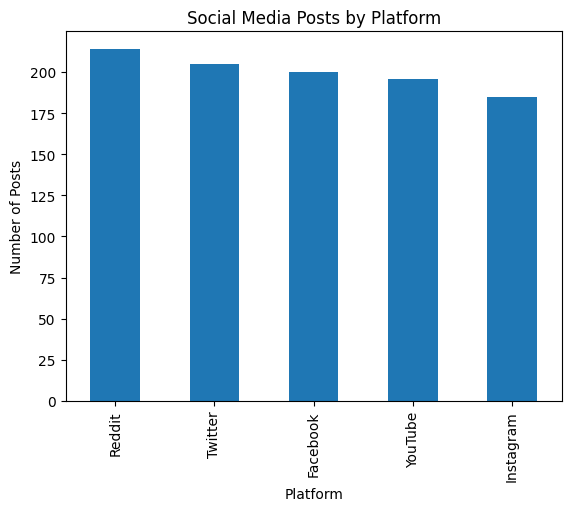

In [8]:
print("Posts by Platform:")

print(df["Platform"].value_counts())

df["Platform"].value_counts().plot(kind="bar")

plt.title("Social Media Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.show()